In [200]:
#
# El dataset HTRU2 contiene mediciones numéricas extraídas de señales de radio para distinguir entre:
# Variables del dataset HTRU2:
#   Profile_mean     — Media del perfil integrado (integrated pulse profile mean)
#   Profile_stdev    — Desviación estándar del perfil integrado (standard deviation of the integrated profile)
#   Profile_kurtosis — Curtosis excesiva del perfil integrado (excess kurtosis of the integrated profile)
#   Profile_skewness — Asimetría del perfil integrado (skewness of the integrated profile)
#
#   DM_mean          — Media de la curva DM-SNR (mean of the DM-SNR curve)
#   DM_stdev         — Desviación estándar de la curva DM-SNR (standard deviation of the DM-SNR curve)
#   DM_kurtosis      — Curtosis excesiva de la curva DM-SNR (excess kurtosis of the DM-SNR curve)
#   DM_skewness      — Asimetría de la curva DM-SNR (skewness of the DM-SNR curve)
#
#   class — clase objetivo: 0 = no pulsar , 1 = pulsar real

import pandas as pd
import numpy as np

# 1. (0,5P) Carga el archivo HTRU_2.csv en un dataframe de pandas.
df = pd.read_csv("./HTRU_2.csv", na_values=["?", "NA", "N/A", "None", "null", "nulo", ""])
# a. (0,1P) Carga el archivo con los posibles valores que puedan identificarse como Nan: ("?", "NA", "N/A", "None", "null", "nulo", "")
#    y muestra su cabecera.
print(df.head())
# b. (0,1P) Muestra las últimas filas del dataframe
print(df.tail())
# c. (0,1P) Dimensiones del dataframe: número de filas y columnas
print(df.shape)
# d. (0,1P) Nombres de las columnas en el formato lista 
print(list(df.columns))
# e. (0,1P) Muestra información general del dataframe. Muestra nombre, tipo de variables, posibles valores nulos y uso de memoria.
print(df.info())

      mean_ip      sd_ip   kurt_ip   skew_ip  mean_dmsnr   sd_dmsnr  \
0  140.562500  55.683782 -0.234571 -0.699648    3.199833  19.110426   
1  102.507812  58.882430  0.465318 -0.515088    1.677258  14.860146   
2  103.015625  39.341649  0.323328  1.051164    3.121237  21.744669   
3  136.750000  57.178449 -0.068415 -0.636238    3.642977  20.959280   
4   88.726562  40.672225  0.600866  1.123492    1.178930  11.468720   

   kurt_dmsnr  skew_dmsnr  class  
0    7.975532   74.242225    NaN  
1   10.576487  127.393580    0.0  
2    7.735822   63.171909    NaN  
3    6.896499   53.593661    NaN  
4   14.269573  252.567306    NaN  
          mean_ip      sd_ip   kurt_ip   skew_ip  mean_dmsnr   sd_dmsnr  \
17893  136.429688  59.847421 -0.187846 -0.738123    1.296823  12.166062   
17894  122.554688  49.485605  0.127978  0.323061   16.409699  44.626893   
17895  119.335938  59.935939  0.159363 -0.743025   21.430602  58.872000   
17896  114.507812  53.902400  0.201161 -0.024789    1.946488  1

In [201]:
# a.
# Con el archivo en el mismo directorio que el cuaderno de Jupyter, lo cargarmos mediante la función read_csv() de la librería pandas.
# Esto crea un DataFrame llamado df con los datos del archivo: HTRU_2.csv'.


In [202]:
# b. Muestra las últimas filas del dataframe


In [203]:
# c. Dimensiones del dataframe: número de filas y columnas
# Dimensiones del dataframe: número de filas y columnas.


In [204]:
# d. Nombres de las columnas en el formato lista. Llama a esta lista 'columnas' e imprímela.
# Crea también una lista de variables predictoras (sin la variable 'class' y llamala 'cols_pred') e imprímela.


In [205]:
# e. Muestra información general del dataframe. Muestra nombre, tipo de variables, posibles valores nulos y uso de memoria.
#    Observa la posible existencia de valores nulos.


In [206]:
#
# 2. (1P) Información sobre las variables del dataframe y valores nulos.

# a. (0,2P) Identifica y muestra numéricamente los valores NaN de este dataset en orden descendente.
nulos = df.isna().sum().sort_values(ascending=False)
nulos

class         5
mean_ip       0
sd_ip         0
skew_ip       0
kurt_ip       0
mean_dmsnr    0
sd_dmsnr      0
kurt_dmsnr    0
skew_dmsnr    0
dtype: int64

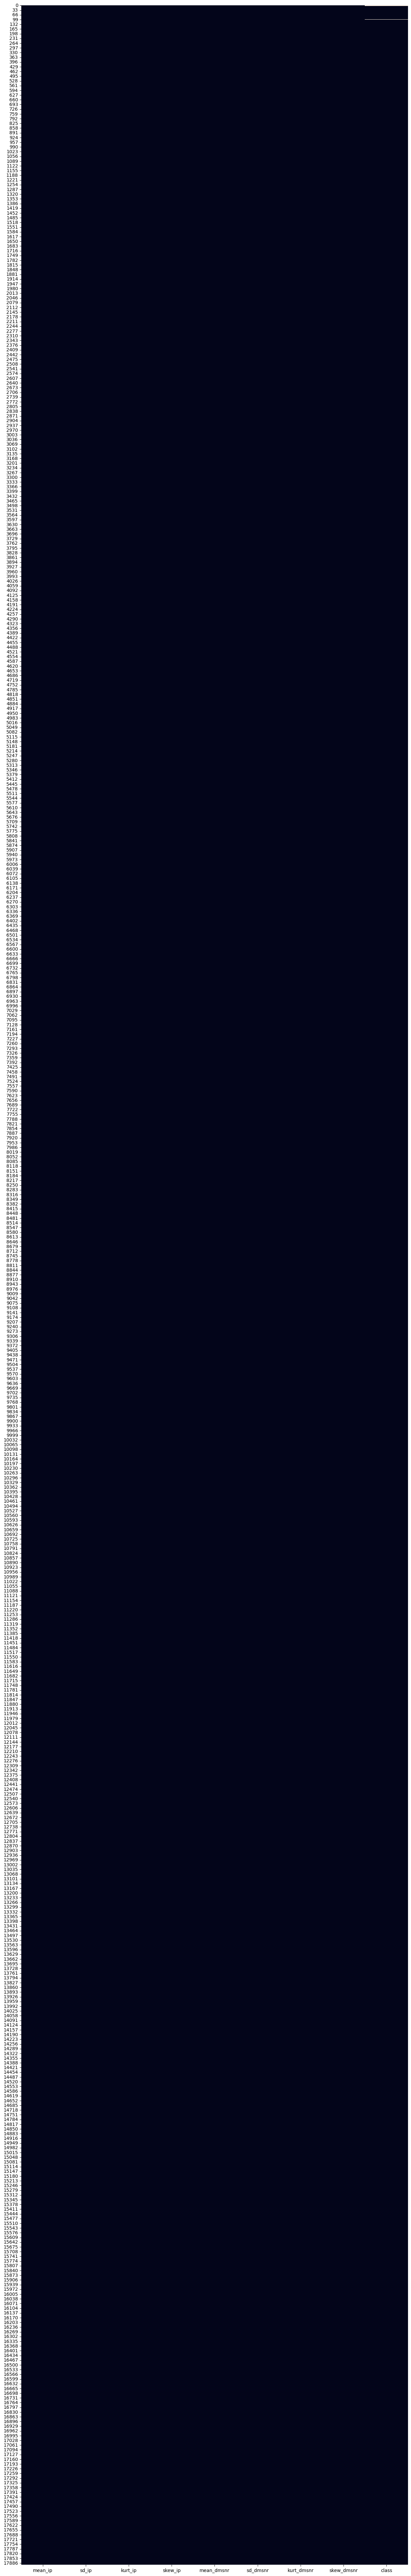

In [207]:
# b. (0,2P) Muestra gráficamente estos valores nulos mediante un mapa de calor. Utiliza figsize=(15,100), para poder visualizar los NaN. 
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(figsize=(15,100))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [208]:
# c. (0,2P) Imputar outilers de la variable categórica 'class' con la moda.

# Calcular la moda (valor más frecuente) de cada columna, ignorando NaN
mode_target = df['class'].mode(dropna=True).iloc[0]

# Rellenar los NaN con la moda correspondiente
df['class'] = df['class'].fillna(mode_target)

# Verficación numérica de que no existen valores Nan en 'class'
print(df["class"].isna().sum())



0


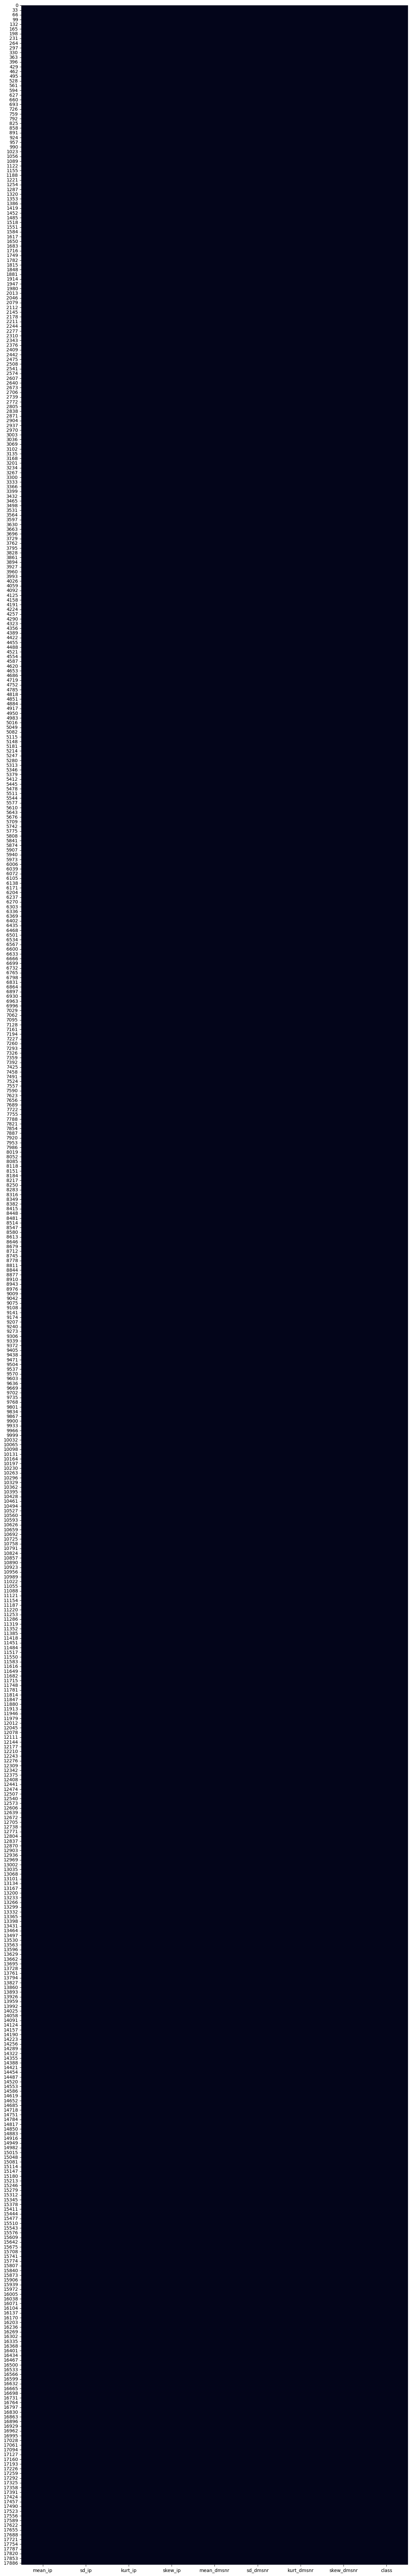

In [209]:
# d. (0,2P) Verifica gráficamente que no existen valores nulos mediante un mapa de calor. Utiliza figsize=(15,100). 
fig, axes = plt.subplots(figsize=(15,100))
sns.heatmap(df.isnull(), cbar=False)
plt.show()


In [210]:

# e. (0,2P) Muestra la distribución de las clases de la variable 'class'. Conviértela al tipo 'int'. Muestra información general del dataframe 
#    para verificar que se ha llevado a cabo el cambio de tipo exitosamente.
df['class'] = df['class'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mean_ip     17898 non-null  float64
 1   sd_ip       17898 non-null  float64
 2   kurt_ip     17898 non-null  float64
 3   skew_ip     17898 non-null  float64
 4   mean_dmsnr  17898 non-null  float64
 5   sd_dmsnr    17898 non-null  float64
 6   kurt_dmsnr  17898 non-null  float64
 7   skew_dmsnr  17898 non-null  float64
 8   class       17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


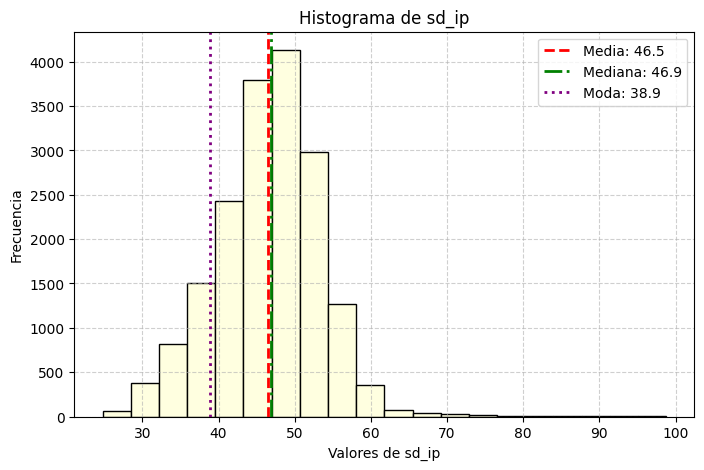

In [211]:
# 3. (1P) 
# a. (0,5P) Construye una función (llámala histograma) que, dado un dataframe y una cadena con el nombre de una variable predictora,
#    muestre el histograma de la variable predictora y líneas de colores para representar la media, la mediana y la moda.
def histograma(df, variable):    

    x = df[variable]

    media = x.mean()            
    mediana = x.median()       
    moda = x.mode()[0]          
    asimetria = x.skew()         

    plt.figure(figsize=(8,5))    
    plt.hist(x, bins=20, color='lightyellow', edgecolor='black') 

    plt.axvline(media, color='red', linestyle='--', linewidth=2, 
                label=f'Media: {media:.1f}')
    plt.axvline(mediana, color='green', linestyle='-.', linewidth=2, 
                label=f'Mediana: {mediana:.1f}')
    plt.axvline(moda, color='purple', linestyle=':', linewidth=2, 
                label=f'Moda: {moda:.1f}')

    plt.title(f'Histograma de {variable}')
    plt.xlabel(f'Valores de {variable}')
    plt.ylabel('Frecuencia')
    plt.legend()                                         
    plt.grid(True, linestyle='--', alpha=0.6)            

    plt.show()           

#    Llama a la función creada, con el dataframe y la variable predictora 'sd_ip'
histograma(df,'sd_ip')

[[<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: >]]
[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: >]


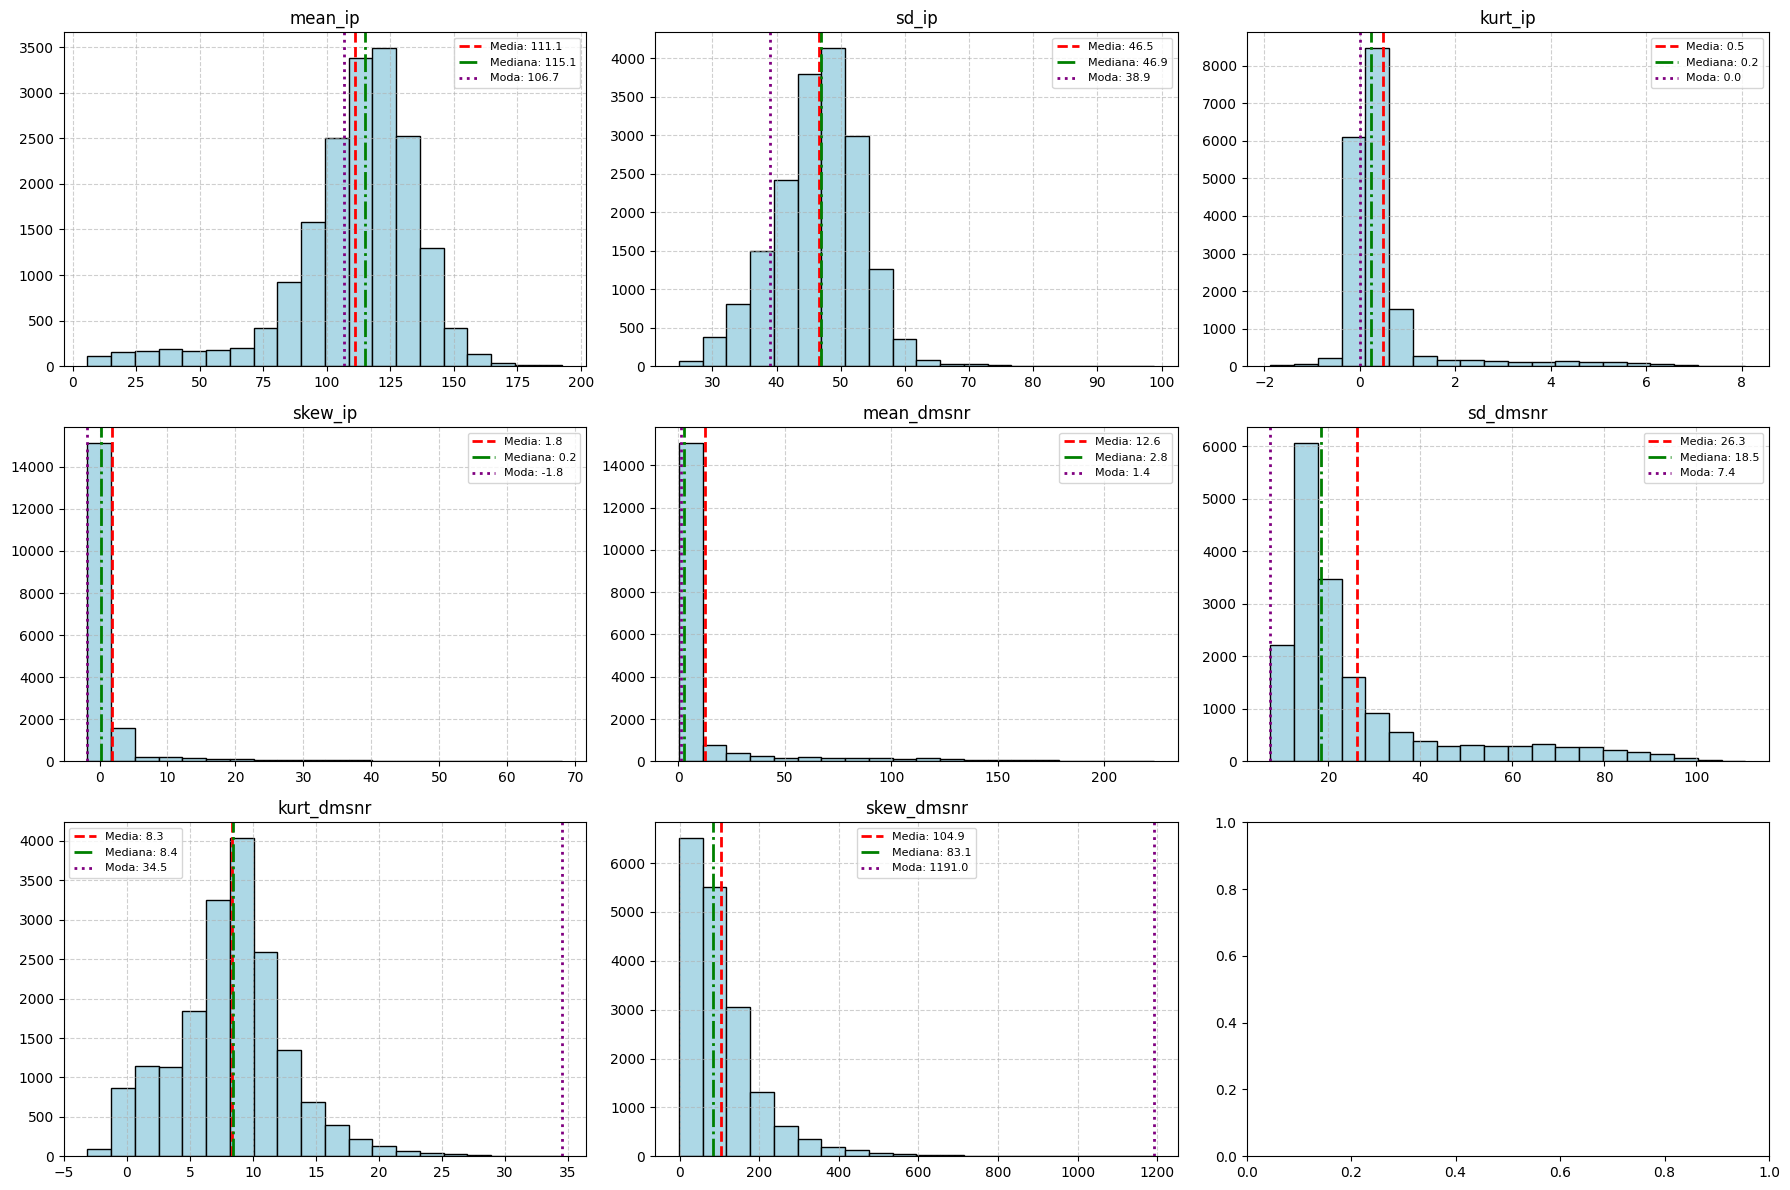

In [212]:
# b. (0,5P) Histogramas de todas las variables PREDICTORAS:

# Crea un función (histogramas) que UTILIZA LA VERSIÓN DE ELECCIÓN AUTOMÁTICA DE NÚMERO DE FILAS Y COLUMNAS PARA GRÁFICOS Y OBTENER 
# SÓLO LAS GRÁFICAS NECESARIAS. Es decir, crea una rejilla de boxplots para varias variables, ajustando automáticamente el número de filas y columnas.
import math
def histogramas(df, variables):
    n_vars = len(variables)
    
    columnas = math.ceil(math.sqrt(n_vars))
    filas = math.ceil(n_vars / columnas)

    fig, axes = plt.subplots(filas, columnas,figsize=(6*columnas, 4*filas) )
    print(axes)
    axes = axes.flatten()  
    print(axes)
    for i, variable in enumerate(variables):
        ax = axes[i]
        x = df[variable].dropna()  

        media = x.mean()
        mediana = x.median()
        moda = x.mode()[0]

        ax.hist(x, bins=20, color='lightblue', edgecolor='black')
        ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.1f}')
        ax.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {mediana:.1f}')
        ax.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.1f}')

        ax.set_title(variable, fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
# Llama a la función histogramas, con el dataframe y la lista 'cols_pred'
cols_pred = variables = df.columns[:-1]    
histogramas(df,cols_pred)


In [213]:
#
# 4. (1P) Correlación entre variables. Matriz de correlación.

# a. (0,25P) Muestra las correlaciones entre las variables del dataset de forma numérica mediante la matriz de correlación
corr_matrix =round(df.corr(),2)
print(corr_matrix)

            mean_ip  sd_ip  kurt_ip  skew_ip  mean_dmsnr  sd_dmsnr  \
mean_ip        1.00   0.55    -0.87    -0.74       -0.30     -0.31   
sd_ip          0.55   1.00    -0.52    -0.54        0.01     -0.05   
kurt_ip       -0.87  -0.52     1.00     0.95        0.41      0.43   
skew_ip       -0.74  -0.54     0.95     1.00        0.41      0.42   
mean_dmsnr    -0.30   0.01     0.41     0.41        1.00      0.80   
sd_dmsnr      -0.31  -0.05     0.43     0.42        0.80      1.00   
kurt_dmsnr     0.23   0.03    -0.34    -0.33       -0.62     -0.81   
skew_dmsnr     0.14   0.03    -0.21    -0.20       -0.35     -0.58   
class         -0.67  -0.36     0.79     0.71        0.40      0.49   

            kurt_dmsnr  skew_dmsnr  class  
mean_ip           0.23        0.14  -0.67  
sd_ip             0.03        0.03  -0.36  
kurt_ip          -0.34       -0.21   0.79  
skew_ip          -0.33       -0.20   0.71  
mean_dmsnr       -0.62       -0.35   0.40  
sd_dmsnr         -0.81       -0.58 

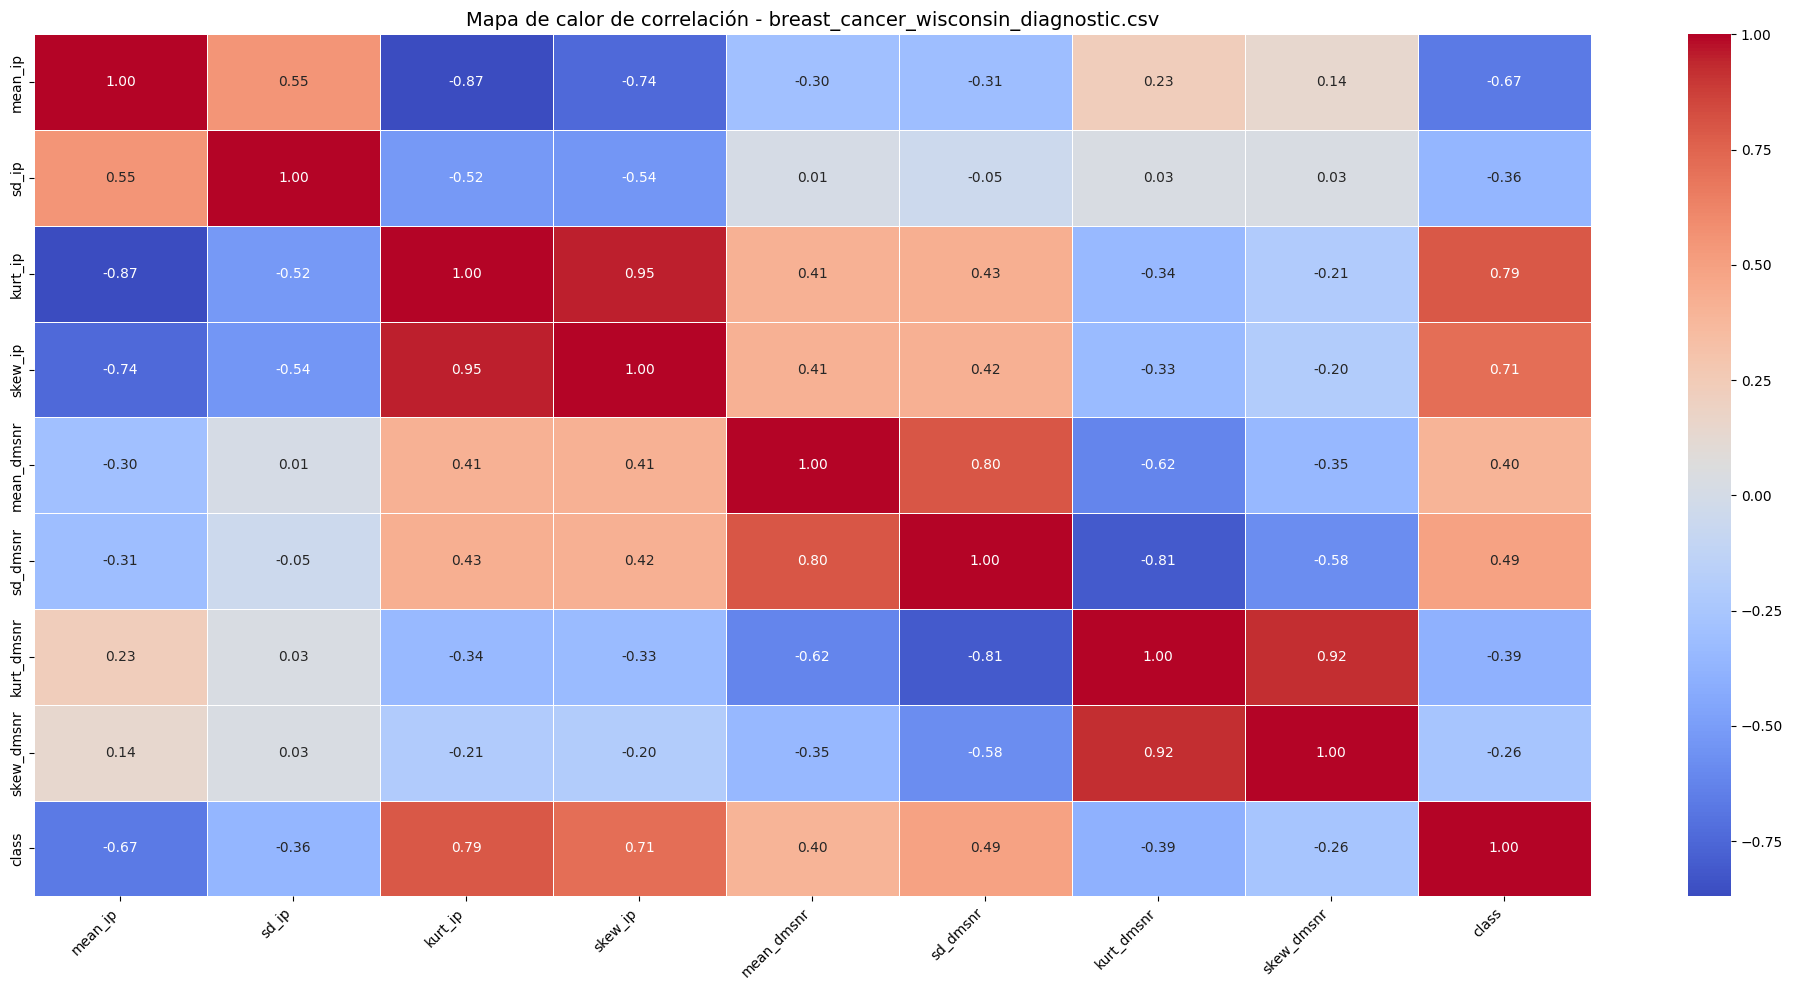

In [214]:
# b. (0,25P) Muestra las correlaciones entre las variables del dataset de forma gráfica mediante un mapa de calor.
import seaborn as sns 
plt.figure(figsize=(20, 10))                       
sns.heatmap(corr_matrix,                         
            annot=True,                          
            cmap='coolwarm',                    
            fmt=".2f",                          
            linewidths=0.5,                     
            cbar=True)                            

plt.title('Mapa de calor de correlación - breast_cancer_wisconsin_diagnostic.csv', fontsize=14)
plt.xticks(rotation=45, ha='right')              
plt.tight_layout()
plt.show()

In [215]:
# c. (0,5P) Crea un script de Python que muestra las correlaciones entre las variables del dataset que presenten
# una correlación clasificada 'muy fuerte', es decir, que el valor de correlación esté en el intervalo 0.8 (incluido) y 1 (excluido).
# Se debe tener en cuenta tanto las correlaciones positivas y negativas.

#se pide (similar a) esta salida:
#Variable 1           Variable 2           Correlación 

#mean_ip              kurt_ip              -0.870    
#kurt_ip              mean_ip              -0.870    
#kurt_ip              skew_ip              0.950     
#skew_ip              kurt_ip              0.950     
#mean_dmsnr           sd_dmsnr             0.800     
#sd_dmsnr             mean_dmsnr           0.800     
#sd_dmsnr             kurt_dmsnr           -0.810    
#kurt_dmsnr           sd_dmsnr             -0.810    
#kurt_dmsnr           skew_dmsnr           0.920     
#skew_dmsnr           kurt_dmsnr           0.920     

plt.figure(figsize=(20, 10))                       

corr_abs = corr_matrix.abs()


corr_pares = corr_abs.unstack()

corr_ordenados = corr_pares.sort_values(ascending=False)


corr_unique = corr_ordenados.drop_duplicates()


corr_alta = corr_unique[(corr_unique >= 0.8) & (corr_unique < 1)]


print("\n Variables altamente correlacionadas (>|0.8|):")
print(corr_alta)


 Variables altamente correlacionadas (>|0.8|):
skew_ip     kurt_ip       0.95
kurt_dmsnr  skew_dmsnr    0.92
kurt_ip     mean_ip       0.87
kurt_dmsnr  sd_dmsnr      0.81
mean_dmsnr  sd_dmsnr      0.80
dtype: float64


<Figure size 2000x1000 with 0 Axes>

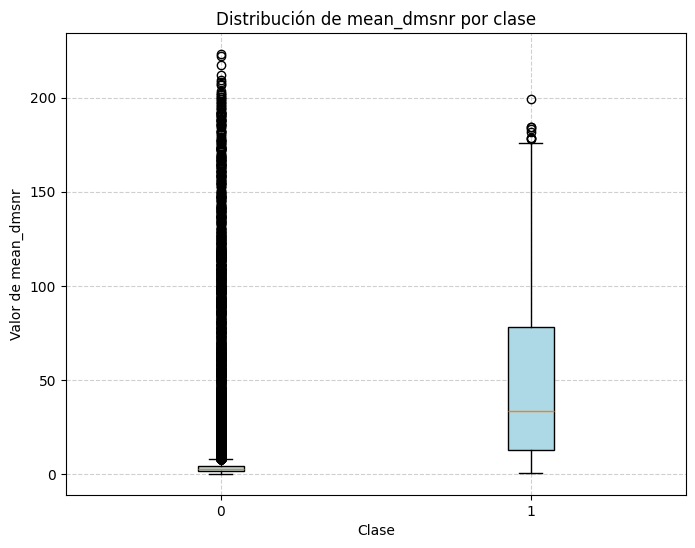

In [216]:

# 5. (1P) Gráficos y análisis de distribución de una variables PREDICTORA por clase. Boxplot.

# a. (0,5P) Construye una función (llámala boxplot_clase) que, dado un dataframe, una cadena con el nombre de una variable predictora y
#    una cadena con la variable objetivo, muestre el boxplot de la variable predictora para cada valor de clase.
#    Utiliza la variable predictora: 'mean_dmsnr'
def boxplot_clase(df, variable):
    
    clases = df['class'].unique()

    datos = [df[df['class'] == c][variable] for c in clases]



    plt.figure(figsize=(8, 6))
    plt.boxplot(
        datos,
        tick_labels=clases,                     
        patch_artist=True,                      
        boxprops=dict(facecolor='lightblue')    
    )

    plt.title(f'Distribución de {variable} por clase')
    plt.xlabel('Clase')
    plt.ylabel(f'Valor de {variable}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

boxplot_clase(df, 'mean_dmsnr')

[0 1]


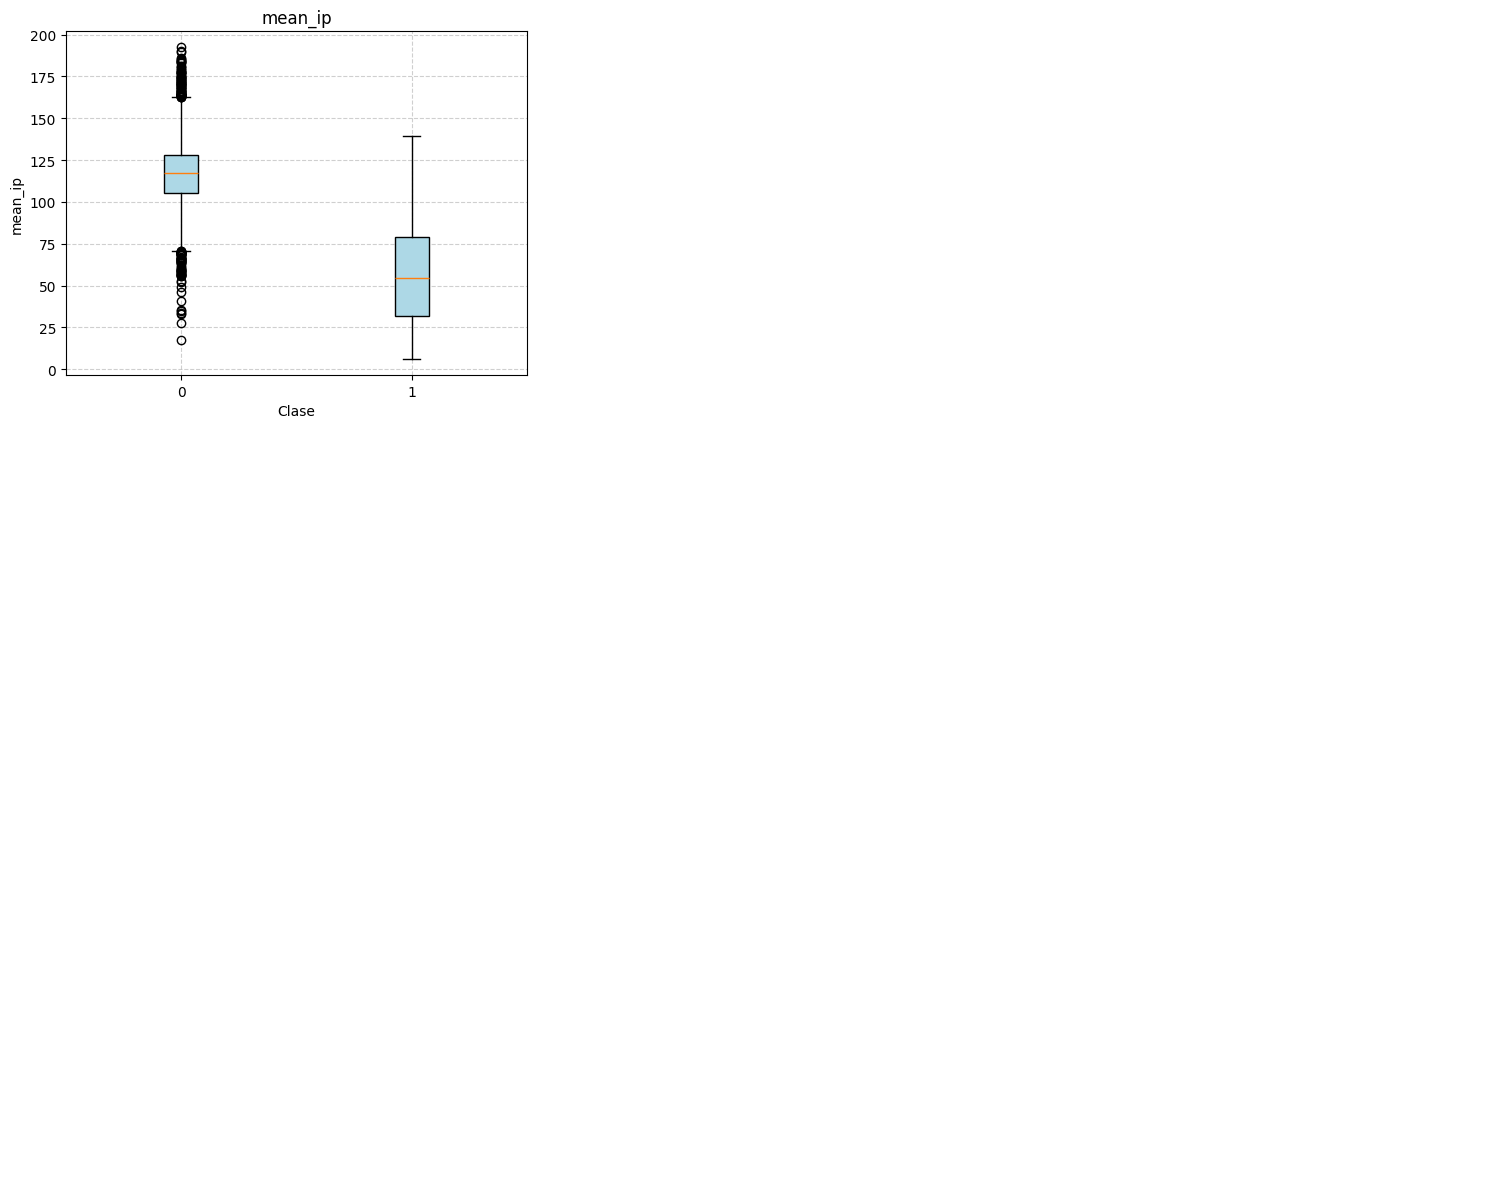

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [217]:
# b. (0,5P) Construye una función (llámala boxplots_clase) que, dado un dataframe, una lista con el nombre de todas las variables predictoras y
#    una cadena con la variable objetivo, muestre los boxplots de las variables predictoras para cada valor de clase.
#    lista variables predictoras: 'cols_pred'
def boxplots_clase(df, variables, target='class'):

    clases = df[target].unique()
    print(df[target].unique())
    n_vars = len(variables)

    columnas = math.ceil(math.sqrt(n_vars))
    filas = math.ceil(n_vars / columnas)

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 4*filas))
    axes = axes.flatten()  

    for i, variable in enumerate(variables):
        ax = axes[i]

        datos = [df[df[target] == c][variable].dropna() for c in clases]

        ax.boxplot(
            datos,
            tick_labels=clases,                  
            patch_artist=True,                   
            boxprops=dict(facecolor='lightblue')
        )

        ax.set_title(variable)
        ax.set_xlabel('Clase')
        ax.set_ylabel(variable)
        ax.grid(True, linestyle='--', alpha=0.6)
        for j in range(i+1, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()
boxplots_clase(df, cols_pred)

In [218]:
#
# 6. (1P) Conjunto de entrenamiento y prueba.
# a. (0,5P) Utiliza el objeto train_test_split y obtén los conjutos de entrenamiento y prueba con 80% y 20% para los conjuntos train y test,
#    respectivamente.
#  NOTA: incluye la opción stratify=y  para mantener la proporción de clases
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class'])
y = df['class']


X_train, X_test, y_train, y_test = train_test_split(
    X,               
    y,                
    test_size=0.2,    
    random_state=42, 
    shuffle=True,  
    stratify=y        
)

In [219]:
# b. (0,25P) Crear un DataFrame con las proporciones porcentuales de los conjuntos: Original, Entrenamiento y Prueba y muéstralo por pantalla
dist = pd.DataFrame({
    'Original': (y.value_counts(normalize=True) * 100).round(2),
    'Entrenamiento': (y_train.value_counts(normalize=True) * 100).round(2),
    'Prueba': (y_test.value_counts(normalize=True) * 100).round(2)
})
dist

,Original,Entrenamiento,Prueba
class,,,
0,90.84,90.84,90.84
1,9.16,9.16,9.16


In [220]:
#
# c. (0,25P) Escalado del Dataset. Realiza el estandarizado de los conjuntos de entrenamiento y test, utilizando el objeto StandardScaler.
scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(X_train)

X_test_std = scaler_std.transform(X_test)


# Cuando hayas terminado este punto, ejecuta el siguiente codigo:

X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns)
X_test_std_df  = pd.DataFrame(X_test_std,  columns=X_test.columns)
print(X_train_std_df.describe())
print(X_test_std_df.describe())


            mean_ip         sd_ip       kurt_ip       skew_ip    mean_dmsnr  \
count  1.431800e+04  1.431800e+04  1.431800e+04  1.431800e+04  1.431800e+04   
mean  -2.506105e-16 -8.118787e-16 -1.786530e-17  2.754234e-17 -3.672312e-17   
std    1.000035e+00  1.000035e+00  1.000035e+00  1.000035e+00  1.000035e+00   
min   -4.113816e+00 -3.195031e+00 -2.215299e+00 -5.768907e-01 -4.217109e-01   
25%   -3.979321e-01 -6.107626e-01 -4.244225e-01 -3.173282e-01 -3.626026e-01   
50%    1.567059e-01  6.265263e-02 -2.389497e-01 -2.549586e-01 -3.321053e-01   
75%    6.286636e-01  6.625616e-01 -6.085400e-03 -1.373652e-01 -2.410127e-01   
max    3.188015e+00  6.655733e+00  7.143980e+00  1.073624e+01  7.289966e+00   

           sd_dmsnr    kurt_dmsnr    skew_dmsnr  
count  1.431800e+04  1.431800e+04  1.431800e+04  
mean   1.746829e-16 -2.064435e-16  1.111619e-16  
std    1.000035e+00  1.000035e+00  1.000035e+00  
min   -9.727236e-01 -2.544784e+00 -1.004257e+00  
25%   -6.100348e-01 -5.621478e-01 -6.5

In [221]:
# 7. KNN (1P)
# (0,25P) Algoritmo KNN (k-Nearest Neighbors). 
# Instancia un objeto de la clase KNeighborsClassifier y llámalo knn. Después, entrénalo con 5 vecinos, distancia euclídea y peso uniforme.
# Realiza las predicciones y calcula el accuracy.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


knn = KNeighborsClassifier(
                           n_neighbors=5,      
                           metric='minkowski', 
                           p=2,               
                           weights='uniform'  
)

knn.fit(X_train_std, y_train)

# Realizar predicciones
y_pred = knn.predict(X_test_std)

# Evaluar las predicciones
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")



Accuracy Score: 0.98


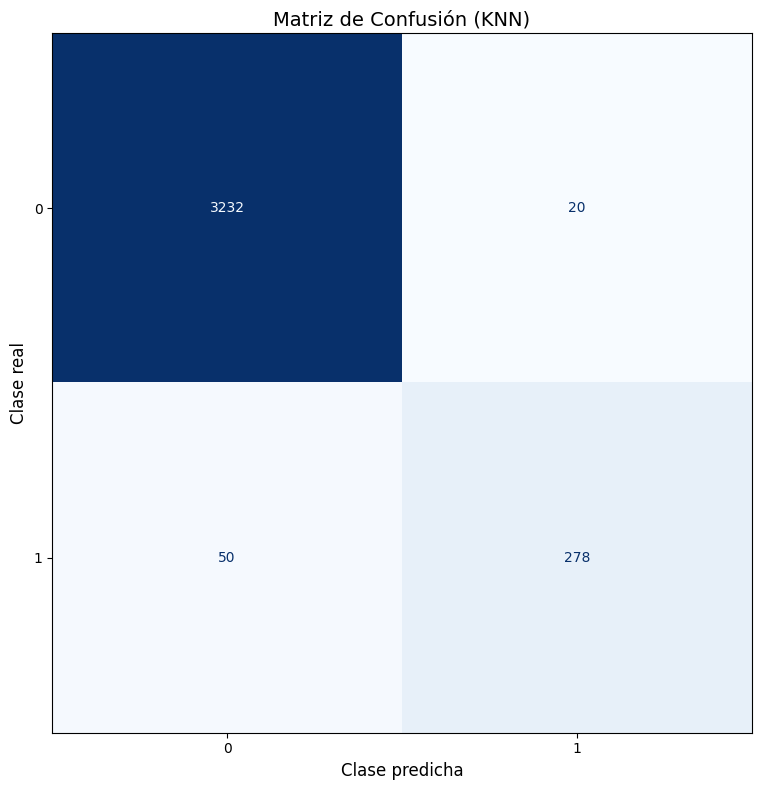

In [222]:
# b. (0,25P) Crea una matriz de confusión con conteos (para KNN). Muéstrala por pantalla.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score


mc = confusion_matrix(y_test, y_pred, labels=knn.classes_)

fig, axes = plt.subplots(figsize=(8, 8))  

disp = ConfusionMatrixDisplay(                            
                             confusion_matrix=mc,         
                             display_labels=knn.classes_ 
                             )
disp.plot(
         cmap="Blues",                                   
         ax=axes,                                        
         colorbar=False                                  
         )

axes.set_title("Matriz de Confusión (KNN)", fontsize=14)
axes.set_xlabel("Clase predicha", fontsize=12)
axes.set_ylabel("Clase real", fontsize=12)
plt.tight_layout()
plt.show()

#### (0,5P) Interpretación de la Matriz de Confusión.
#### Completa la siguiente tabla, teniendo en cuenta que: clase 0 = no pulsar , clase 1 = pulsar real

| Tipo                     | Significado                                                                         | Valor |
| ------------------------ | ----------------------------------------------------------------------------------- | ----- |
| TN (True negatives)    | Casos *no pulsar* correctamente clasificados como    *no pulsar* (0 lo clasifica como 0). |   3232    |
| TP (True Positives)    | Casos *pulsar*    correctamente clasificados como    *pulsar* (1 lo clasifica como 1). |    278   |
| FN   (False Negatives)   | Casos *pulsar*    clasificados erróneamente como     *no pulsar* (1 lo clasifica como 0). |    50   |
| FP   (False Positives)   | Casos *no pulsar* clasificados erróneamente como     *pulsar* (0 lo clasifica como 1). |    20   |


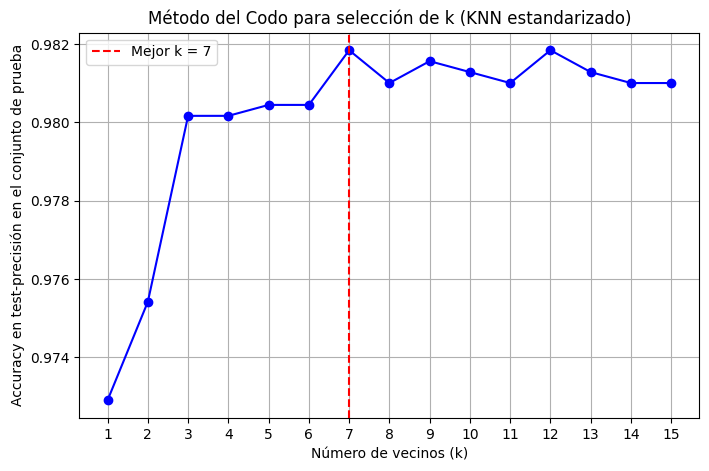

Mejor valor de k: 7 con Accuracy = 0.982


In [223]:
# 8. (1P)

# a. (0,5P) Crea una función f_knn que reciba un valor de k (número de vecinos) como parámetro y devuelva un objeto knn (return knn).
# Utiliza los mísmos parametros para el objeto knn de la celda 42.
def f_knn(k):
    knn = KNeighborsClassifier(
        n_neighbors=k,      
        metric='minkowski', 
        p=2,
        weights='uniform'   
    )
    return knn

# b. (0,5P) Cálcula el valor óptimo del número de vecinos mediante el MÉTODO DEL CODO (ELBOW METHOD) CON DATOS ESTANDARIZADOS.
#     Itera con la función f_knn del dentro del bucle for -dónde se entrena y evalúa el modelo para cada k-. Sin este cambio, el punto no será válido.
#     Muestra la gráfica y el valor óptimo de k. Utiliza un rango de k desde 1 a 15
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = f_knn(k)
    knn.fit(X_train_std, y_train)
    y_pred = knn.predict(X_test_std)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Método del Codo para selección de k (KNN estandarizado)')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy en test-precisión en el conjunto de prueba')
plt.xticks(k_values)
plt.grid(True)

best_k = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)
plt.axvline(best_k, color='r', linestyle='--', label=f'Mejor k = {best_k}')
plt.legend()
plt.show()

print(f"Mejor valor de k: {best_k} con Accuracy = {best_acc:.3f}")

AUC: 0.9574431681816817


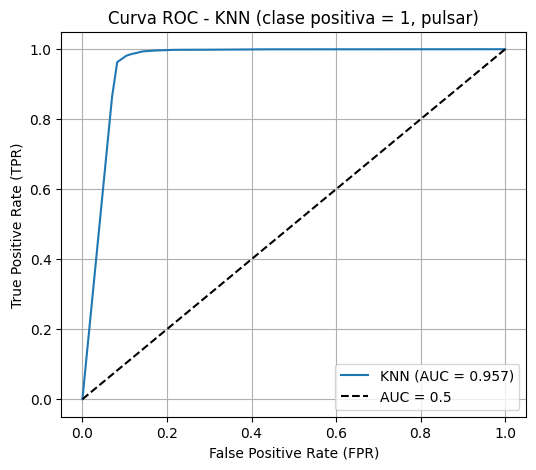

In [224]:
# 9. (1P) Crea la curva ROC para este modelo.
# Ten en cuenta que 0 corresponde a 'no_pulsar' y 1 corresponde a 'pulsar'. Es decir, la clase positiva es 1
# Utiliza la función f_knn con el k óptimo para realizar las predicciones. Adapta la presentación de la curva ROC a las variables de este dataset.
from sklearn.metrics import roc_curve, auc

y_proba = knn.predict_proba(X_test_std)

y_scores = y_proba[:, 0]  

fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label=0)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='AUC = 0.5')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - KNN (clase positiva = 1, pulsar)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#### 10. (1,5P) Validación Cruzada. La clase StratifiedKFold

#### a) Instancia un objeto de la clase StratifiedKFold, baraja los resultados (*shuffle*), utiliza 5 folds y establece una semilla.
#### Calcula las siguientes métricas:

| Métrica                 | Fórmula por fold i |
|-------------------------|--------------------|
| Accuracy                | (TPᵢ + TNᵢ) / (TPᵢ + TNᵢ + FPᵢ + FNᵢ) |
| Precision (malignos)    | TPᵢ / (TPᵢ + FPᵢ) |
| Recall / Sensibilidad   | TPᵢ / (TPᵢ + FNᵢ) |
| F1-score                | 2 * (Precisionᵢ * Recallᵢ) / (Precisionᵢ + Recallᵢ) |
| Specificity (benignos)  | TNᵢ / (TNᵢ + FPᵢ) |
| Balanced Accuracy       | 1/2 * (Recallᵢ + Specificityᵢ) |
| Promedio final          | (1/k) * Σ Mᵢ |
| Varianza                | (1/k) * Σ (Mᵢ - M_final)² |
| Desviación estándar     | sqrt(Var(M)) |

#### Es obligatorio utilizar la función f_knn pedida en el punto 8 a) con el valor del k óptimo. Esta función devuelve un objeto knn que se
#### debe utilizar en cada iteración en la que se ntrena y predice con los conjuntos de entrenamiento y test de cada fold.
#### Muestra los resultados por métrica en la forma: (media ± desviación):

In [225]:
from sklearn.model_selection import StratifiedKFold


from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,     
    precision_score,    
    recall_score,       
    f1_score,           
    confusion_matrix    
)

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42 
)

results = {
    "accuracy": [],
    "precision_0": [],
    "recall_0": [],
    "specificity_1": [],
    "f1_0": [],
    "balanced_accuracy": []
}
X = df.drop(columns=['class']).values   
y = df['class'].values                 


for train_idx, test_idx in kf.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

   
    scaler = StandardScaler()

    X_train_std = scaler.fit_transform(X_train)

    X_test_std = scaler.transform(X_test)

    f_knn(best_k)

    knn.fit(X_train_std, y_train)

    y_pred = knn.predict(X_test_std)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=0)

    rec = recall_score(y_test, y_pred, pos_label=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    spec = tn / (tn + fp)

    f1 = f1_score(y_test, y_pred, pos_label=0)

    bal_acc = (rec + spec) / 2

    results["accuracy"].append(acc)
    results["precision_0"].append(prec)
    results["recall_0"].append(rec)
    results["specificity_1"].append(spec)
    results["f1_0"].append(f1)
    results["balanced_accuracy"].append(bal_acc)

print("\nResultados por métrica (media ± desviación):\n")

for metric, values in results.items():
    print(f"{metric:20s}: {np.mean(values):.4f}  ±  {np.std(values):.4f}")


Resultados por métrica (media ± desviación):

accuracy            : 0.9782  ±  0.0020
precision_0         : 0.9816  ±  0.0015
recall_0            : 0.9946  ±  0.0016
specificity_1       : 0.9946  ±  0.0016
f1_0                : 0.9881  ±  0.0011
balanced_accuracy   : 0.9946  ±  0.0016
